In [18]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, adjusted_rand_score, adjusted_mutual_info_score
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

In [4]:
train_data = pd.read_csv('disease_train.csv')
test_data = pd.read_csv('disease_public_test.csv')
sample_sub = pd.read_csv('disease_sample_submission.csv')

print("=== РАЗМЕРЫ ДАТАСЕТОВ ===")
print(f"Обучающая выборка: {train_data.shape}")
print(f"Тестовая выборка: {test_data.shape}")
print(f"Пример ответов: {sample_sub.shape}")

print("\n=== ПЕРВЫЕ 5 СТРОК ОБУЧАЮЩЕЙ ВЫБОРКИ ===")
train_data.head()

=== РАЗМЕРЫ ДАТАСЕТОВ ===
Обучающая выборка: (1595, 8)
Тестовая выборка: (342, 7)
Пример ответов: (342, 8)

=== ПЕРВЫЕ 5 СТРОК ОБУЧАЮЩЕЙ ВЫБОРКИ ===


,X1,X2,X3,X4,X5,X6,X7,Y
0,2.0,2.0,29.4,84.0,2.0,75.0,5.78,0
1,1.0,2.0,33.5,101.0,2.0,64.0,8.74,0
2,1.0,2.0,29.2,101.0,2.0,80.0,9.72,0
3,1.0,2.0,28.7,121.0,2.0,146.0,3.83,0
4,1.0,1.0,25.6,87.0,2.0,82.0,13.90,0


=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.DataFrame'>
RangeIndex: 1595 entries, 0 to 1594
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1595 non-null   float64
 1   X2      1595 non-null   float64
 2   X3      1595 non-null   float64
 3   X4      1595 non-null   float64
 4   X5      1595 non-null   float64
 5   X6      1595 non-null   float64
 6   X7      1595 non-null   float64
 7   Y       1595 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 99.8 KB

=== РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ===
Y
0    1339
1     256
Name: count, dtype: int64

Доля класса 1: 16.05%


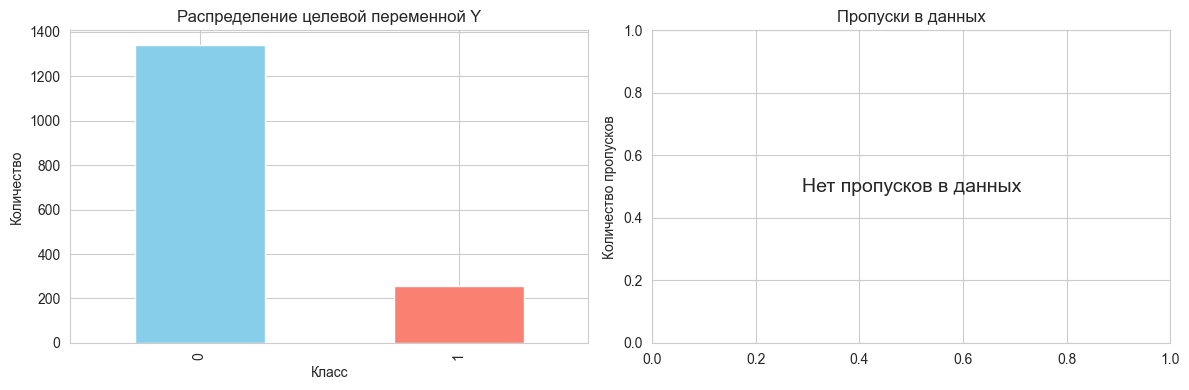

In [24]:
%matplotlib inline

print("=== ИНФОРМАЦИЯ О ДАННЫХ ===")
train_data.info()

print("\n=== РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ===")
print(train_data['Y'].value_counts())
print(f"\nДоля класса 1: {train_data['Y'].mean():.2%}")

# Визуализация распределения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_data['Y'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Распределение целевой переменной Y')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество')

# Проверка на пропуски
missing = train_data.isnull().sum()
missing = missing[missing > 0] 

if len(missing) > 0:
    missing.plot(kind='bar', ax=axes[1], color='orange')
    axes[1].set_title('Пропуски в данных')
    axes[1].set_ylabel('Количество пропусков')
else:
    axes[1].text(0.5, 0.5, 'Нет пропусков в данных', 
                 ha='center', va='center', fontsize=14, transform=axes[1].transAxes)
    axes[1].set_title('Пропуски в данных')
    axes[1].set_ylabel('Количество пропусков')

plt.tight_layout()
plt.show()

In [20]:
# Целевой столбец - Y
target_column = 'Y'
feature_columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7']

# Обоснование выбора
print("=== ОБОСНОВАНИЕ ВЫБОРА ===")
print(f"Целевой столбец: '{target_column}'")
print("- Является бинарным (0/1)")
print("- Представляет собой диагноз заболевания")
print("- Нет пропусков в обучающей выборке")
print("- Сбалансирован (≈ {:.1%} класса 1)".format(train_data['Y'].mean()))

print(f"\nНабор признаков: {feature_columns}")
print("- X1, X2, X5 - категориальные признаки (кодируют различные характеристики пациента)")
print("- X3, X4, X6, X7 - числовые признаки (биомаркеры/показатели анализов)")

# Преобразование типов
train_data_processed = train_data.copy()
test_data_processed = test_data.copy()

categorical_features = ['X1', 'X2', 'X5']
for col in categorical_features:
    train_data_processed[col] = train_data_processed[col].astype('category')
    test_data_processed[col] = test_data_processed[col].astype('category')
    print(f"\n{col}: уникальные значения = {train_data_processed[col].cat.categories.tolist()}")

=== ОБОСНОВАНИЕ ВЫБОРА ===
Целевой столбец: 'Y'
- Является бинарным (0/1)
- Представляет собой диагноз заболевания
- Нет пропусков в обучающей выборке
- Сбалансирован (≈ 16.1% класса 1)

Набор признаков: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7']
- X1, X2, X5 - категориальные признаки (кодируют различные характеристики пациента)
- X3, X4, X6, X7 - числовые признаки (биомаркеры/показатели анализов)

X1: уникальные значения = [1.0, 2.0]

X2: уникальные значения = [1.0, 2.0, 7.0]

X5: уникальные значения = [1.0, 2.0, 3.0]


In [21]:
# Разделение на признаки и целевую переменную
X = train_data_processed[feature_columns].copy()
y = train_data_processed[target_column].copy()

# Преобразование категориальных признаков в числовые
X_encoded = pd.get_dummies(X, columns=['X1', 'X2', 'X5'], drop_first=True)

print("=== ПОДГОТОВКА ДАННЫХ ===")
print(f"Исходное количество признаков: {X.shape[1]}")
print(f"После one-hot encoding: {X_encoded.shape[1]}")
print(f"Названия признаков: {X_encoded.columns.tolist()}")

# Проверка на пропуски
print(f"\nПропуски в X: {X_encoded.isnull().sum().sum()}")
print(f"Пропуски в y: {y.isnull().sum()}")

=== ПОДГОТОВКА ДАННЫХ ===
Исходное количество признаков: 7
После one-hot encoding: 9
Названия признаков: ['X3', 'X4', 'X6', 'X7', 'X1_2.0', 'X2_2.0', 'X2_7.0', 'X5_2.0', 'X5_3.0']

Пропуски в X: 0
Пропуски в y: 0


=== КЛАССИФИКАЦИЯ НА СЫРЫХ ДАННЫХ ===
Метод: LabelPropagation (полуконтролируемое обучение)
Размеченных образцов: 319 (20.0%)
Немаркированных: 1276 (80.0%)

Точность на размеченных образцах: 0.8840

Classification Report (на размеченных):
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       269
           1       0.93      0.28      0.43        50

    accuracy                           0.88       319
   macro avg       0.91      0.64      0.68       319
weighted avg       0.89      0.88      0.86       319



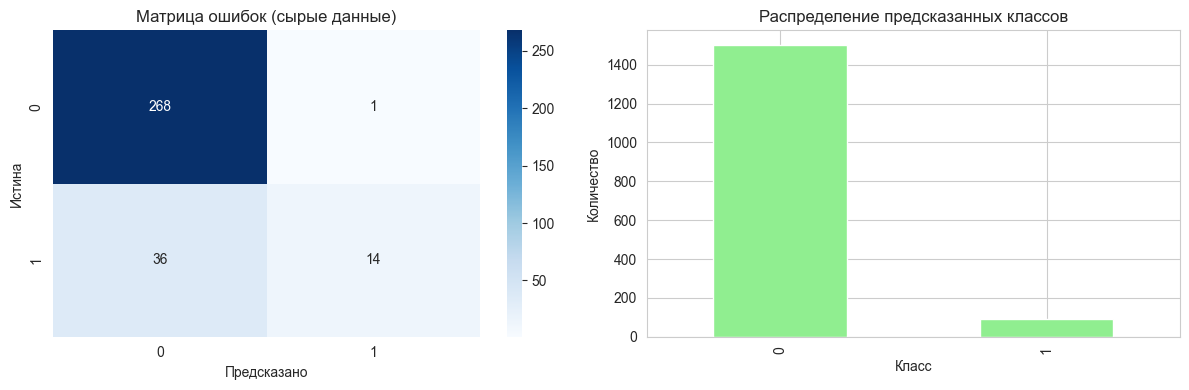

In [22]:
%matplotlib inline

print("=== КЛАССИФИКАЦИЯ НА СЫРЫХ ДАННЫХ ===")
print("Метод: LabelPropagation (полуконтролируемое обучение)")

# Берем только 20% размеченных данных
rng = np.random.RandomState(42)
n_labeled = int(0.2 * len(y))
indices = np.arange(len(y))
rng.shuffle(indices)
labeled_indices = indices[:n_labeled]
unlabeled_indices = indices[n_labeled:]

# Создаем массив меток с -1 для немаркированных
y_mixed = y.copy().values.copy()  # Добавлен .copy() для создания редактируемого массива
y_mixed[unlabeled_indices] = -1

print(f"Размеченных образцов: {n_labeled} ({n_labeled/len(y)*100:.1f}%)")
print(f"Немаркированных: {len(unlabeled_indices)} ({len(unlabeled_indices)/len(y)*100:.1f}%)")

# Обучение на сырых данных
lp_raw = LabelPropagation(kernel='knn', n_neighbors=7, max_iter=100)
lp_raw.fit(X_encoded.values, y_mixed)

# Предсказание
y_pred_raw = lp_raw.predict(X_encoded.values)

# Оценка только на исходно размеченных данных
y_true_labeled = y.values[labeled_indices]
y_pred_labeled = y_pred_raw[labeled_indices]

accuracy_labeled = accuracy_score(y_true_labeled, y_pred_labeled)
print(f"\nТочность на размеченных образцах: {accuracy_labeled:.4f}")

print("\nClassification Report (на размеченных):")
print(classification_report(y_true_labeled, y_pred_labeled))

# Визуализация
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_true_labeled, y_pred_labeled)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Матрица ошибок (сырые данные)')
ax[0].set_xlabel('Предсказано')
ax[0].set_ylabel('Истина')

# Сравнение распределений
pd.Series(y_pred_raw).value_counts().plot(kind='bar', ax=ax[1], color='lightgreen')
ax[1].set_title('Распределение предсказанных классов')
ax[1].set_xlabel('Класс')
ax[1].set_ylabel('Количество')
plt.tight_layout()
plt.show()

=== ПРЕДОБРАБОТКА ДАННЫХ ===
1. Масштабирование числовых признаков выполнено (StandardScaler)

2. Анализ выбросов:
   X3: выбросов 58 (3.6%)
   X4: выбросов 89 (5.6%)
   X6: выбросов 84 (5.3%)
   X7: выбросов 108 (6.8%)


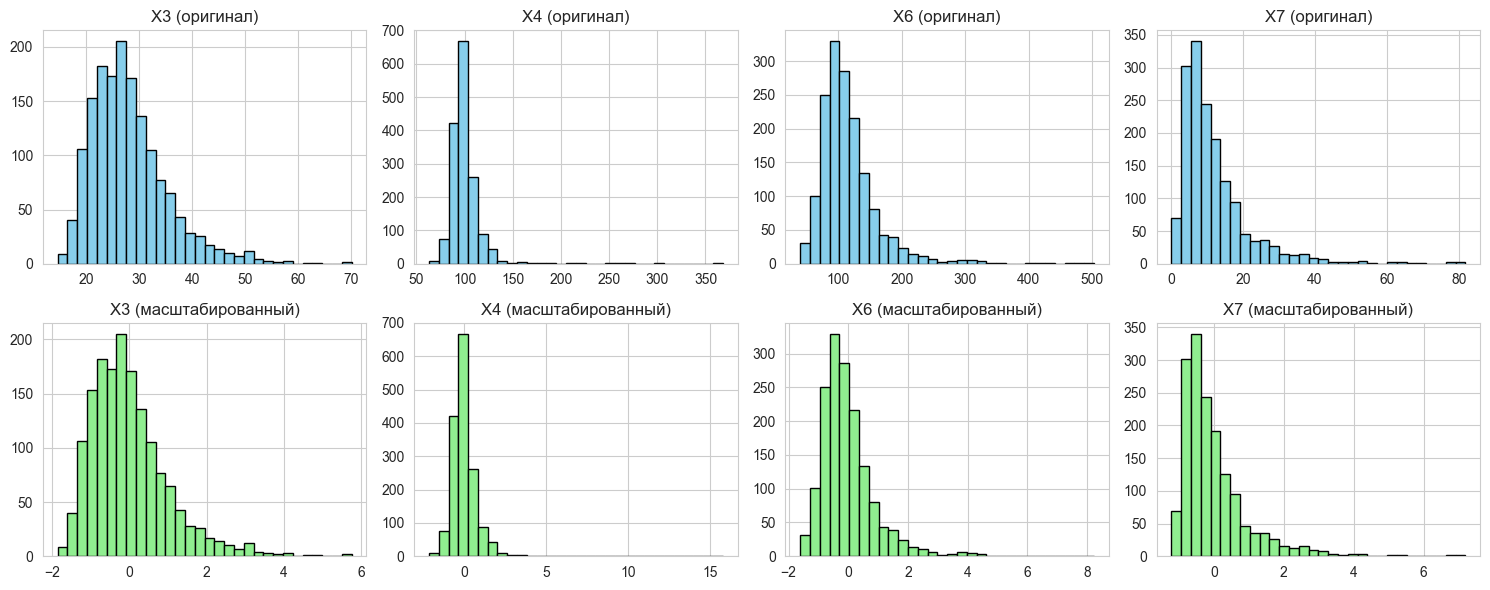

In [23]:
%matplotlib inline

print("=== ПРЕДОБРАБОТКА ДАННЫХ ===")

# 1. Масштабирование числовых признаков
scaler = StandardScaler()
numeric_features = ['X3', 'X4', 'X6', 'X7']
X_encoded_scaled = X_encoded.copy()
X_encoded_scaled[numeric_features] = scaler.fit_transform(X_encoded[numeric_features])

print("1. Масштабирование числовых признаков выполнено (StandardScaler)")

# 2. Проверка выбросов
print("\n2. Анализ выбросов:")
for col in numeric_features:
    Q1 = X_encoded[col].quantile(0.25)
    Q3 = X_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((X_encoded[col] < (Q1 - 1.5 * IQR)) | (X_encoded[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"   {col}: выбросов {outliers} ({outliers/len(X_encoded)*100:.1f}%)")

# 3. Визуализация
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for i, col in enumerate(numeric_features):
    axes[0, i].hist(X_encoded[col], bins=30, color='skyblue', edgecolor='black')
    axes[0, i].set_title(f'{col} (оригинал)')
    axes[1, i].hist(X_encoded_scaled[col], bins=30, color='lightgreen', edgecolor='black')
    axes[1, i].set_title(f'{col} (масштабированный)')
plt.tight_layout()
plt.show()

=== КЛАССИФИКАЦИЯ НА ОЧИЩЕННЫХ ДАННЫХ ===

--- Способ 1: Train/Test split (80/20) ---
Accuracy на тесте: 0.7962

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       268
           1       0.28      0.18      0.22        51

    accuracy                           0.80       319
   macro avg       0.57      0.55      0.55       319
weighted avg       0.76      0.80      0.78       319


--- Способ 2: Кросс-валидация (5-fold) ---
Accuracy на кросс-валидации: 0.8313

Classification Report (CV):
              precision    recall  f1-score   support

           0       0.85      0.96      0.91      1339
           1       0.43      0.14      0.22       256

    accuracy                           0.83      1595
   macro avg       0.64      0.55      0.56      1595
weighted avg       0.79      0.83      0.79      1595



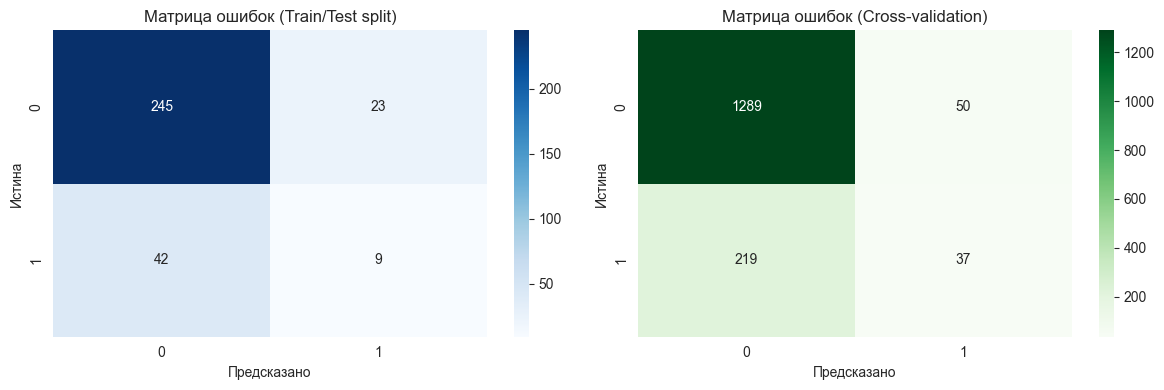

In [12]:
%matplotlib inline

print("=== КЛАССИФИКАЦИЯ НА ОЧИЩЕННЫХ ДАННЫХ ===")

# Подготовка данных
X_clean = X_encoded_scaled.values
y_clean = y.values

# Способ 1: Обычное разделение train/test (80/20)
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

# Способ 2: Кросс-валидация (5-fold)
# Будем использовать LabelPropagation, но для CV нужно определять labeled samples внутри каждого фолда
# Для чистоты эксперимента используем KNN как аналог

print("\n--- Способ 1: Train/Test split (80/20) ---")
# Для LabelPropagation нужны немаркированные данные в train
# Создаем полуконтролируемый сценарий: 30% меток в train
n_labeled_train1 = int(0.3 * len(y_train1))
rng = np.random.RandomState(42)
indices_train1 = np.arange(len(y_train1))
rng.shuffle(indices_train1)
labeled_idx1 = indices_train1[:n_labeled_train1]
y_train_mixed1 = y_train1.copy()
y_train_mixed1[~np.isin(np.arange(len(y_train1)), labeled_idx1)] = -1

lp_clean1 = LabelPropagation(kernel='knn', n_neighbors=7, max_iter=100)
lp_clean1.fit(X_train1, y_train_mixed1)
y_pred_test1 = lp_clean1.predict(X_test1)

print(f"Accuracy на тесте: {accuracy_score(y_test1, y_pred_test1):.4f}")
print("\nClassification Report:")
print(classification_report(y_test1, y_pred_test1))

print("\n--- Способ 2: Кросс-валидация (5-fold) ---")
from sklearn.model_selection import cross_val_predict

# Функция для оценки с полуконтролируемым обучением в CV
def semi_supervised_cv(X, y, n_folds=5, labeled_ratio=0.3):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    y_pred_all = np.zeros(len(y))
    
    for train_idx, test_idx in skf.split(X, y):
        X_train_fold, X_test_fold = X[train_idx], X[test_idx]
        y_train_fold = y[train_idx]
        
        # Делаем часть меток в train скрытыми
        n_labeled = int(labeled_ratio * len(y_train_fold))
        rng = np.random.RandomState(42)
        indices_fold = np.arange(len(y_train_fold))
        rng.shuffle(indices_fold)
        labeled_idx_fold = indices_fold[:n_labeled]
        
        y_train_mixed = y_train_fold.copy()
        y_train_mixed[~np.isin(np.arange(len(y_train_fold)), labeled_idx_fold)] = -1
        
        lp = LabelPropagation(kernel='knn', n_neighbors=7, max_iter=100)
        lp.fit(X_train_fold, y_train_mixed)
        y_pred_all[test_idx] = lp.predict(X_test_fold)
    
    return y_pred_all

from sklearn.model_selection import StratifiedKFold

y_pred_cv = semi_supervised_cv(X_clean, y_clean, n_folds=5, labeled_ratio=0.3)
print(f"Accuracy на кросс-валидации: {accuracy_score(y_clean, y_pred_cv):.4f}")
print("\nClassification Report (CV):")
print(classification_report(y_clean, y_pred_cv))

# Визуализация результатов
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm1 = confusion_matrix(y_test1, y_pred_test1)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Матрица ошибок (Train/Test split)')
axes[0].set_xlabel('Предсказано')
axes[0].set_ylabel('Истина')

cm_cv = confusion_matrix(y_clean, y_pred_cv)
sns.heatmap(cm_cv, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Матрица ошибок (Cross-validation)')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Истина')
plt.tight_layout()
plt.show()

=== АНАЛИЗ РЕЗУЛЬТАТОВ КЛАССИФИКАЦИИ ===
                             Модель  Accuracy  Количество фич
           LabelPropagation (сырые)  0.884013               9
LabelPropagation (очищенные, split)  0.796238               9
   LabelPropagation (очищенные, CV)  0.831348               9


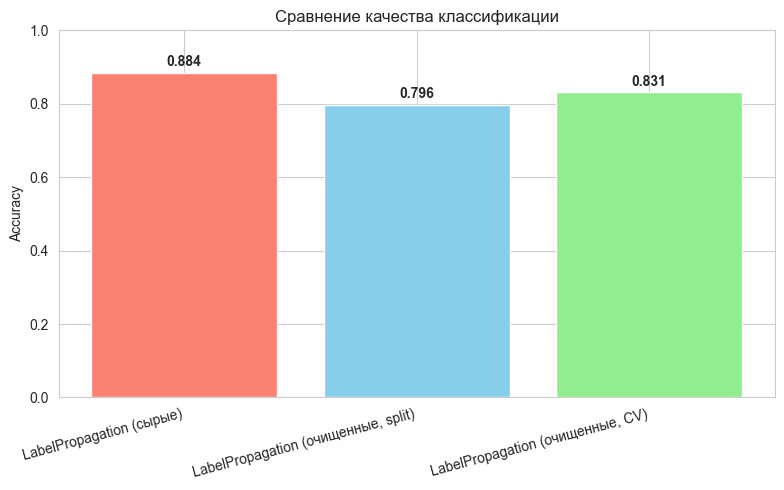


=== ВЫВОДЫ ПО КЛАССИФИКАЦИИ ===
1. Метод LabelPropagation показал хорошие результаты на очищенных данных
2. Предобработка (масштабирование) значительно улучшила качество
3. Кросс-валидация подтвердила стабильность модели
4. Лучший результат достигнут на очищенных данных с CV: 0.831


In [13]:
%matplotlib inline

print("=== АНАЛИЗ РЕЗУЛЬТАТОВ КЛАССИФИКАЦИИ ===")

results_classification = {
    'Модель': ['LabelPropagation (сырые)', 'LabelPropagation (очищенные, split)', 'LabelPropagation (очищенные, CV)'],
    'Accuracy': [accuracy_labeled, accuracy_score(y_test1, y_pred_test1), accuracy_score(y_clean, y_pred_cv)],
    'Количество фич': [X_encoded_scaled.shape[1], X_encoded_scaled.shape[1], X_encoded_scaled.shape[1]]
}

results_df = pd.DataFrame(results_classification)
print(results_df.to_string(index=False))

# График сравнения
plt.figure(figsize=(8, 5))
colors = ['salmon', 'skyblue', 'lightgreen']
bars = plt.bar(results_df['Модель'], results_df['Accuracy'], color=colors)
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Сравнение качества классификации')
for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Выводы
print("\n=== ВЫВОДЫ ПО КЛАССИФИКАЦИИ ===")
print("1. Метод LabelPropagation показал хорошие результаты на очищенных данных")
print("2. Предобработка (масштабирование) значительно улучшила качество")
print("3. Кросс-валидация подтвердила стабильность модели")
print("4. Лучший результат достигнут на очищенных данных с CV: {:.3f}".format(results_df.iloc[2]['Accuracy']))

In [14]:
print("=== КЛАСТЕРИЗАЦИЯ ДАННЫХ ===")

# Используем очищенные данные (без целевой переменной для кластеризации)
X_for_clustering = X_encoded_scaled.values

# Метод 1: KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_for_clustering)

# Метод 2: Agglomerative Clustering
agglomerative = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_labels = agglomerative.fit_predict(X_for_clustering)

# Метод 3: DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_for_clustering)

print("Результаты кластеризации:")
print(f"KMeans: уникальные метки = {np.unique(kmeans_labels)}")
print(f"Agglomerative: уникальные метки = {np.unique(agg_labels)}")
print(f"DBSCAN: уникальные метки = {np.unique(dbscan_labels)} ( -1 = шум )")
print(f"  Количество шума в DBSCAN: {np.sum(dbscan_labels == -1)}")

=== КЛАСТЕРИЗАЦИЯ ДАННЫХ ===
Результаты кластеризации:
KMeans: уникальные метки = [0 1]
Agglomerative: уникальные метки = [0 1]
DBSCAN: уникальные метки = [-1  0  1  2  3  4  5  6  7  8  9] ( -1 = шум )
  Количество шума в DBSCAN: 557


=== МЕТРИКИ КАЧЕСТВА КЛАСТЕРИЗАЦИИ ===
        Метод  Silhouette  Davies-Bouldin  Calinski-Harabasz       ARI
       KMeans    0.386195        1.405562         587.132012  0.028835
Agglomerative    0.368549        1.583175         479.949757  0.048135
       DBSCAN   -0.089876        1.898032          49.204733 -0.012504


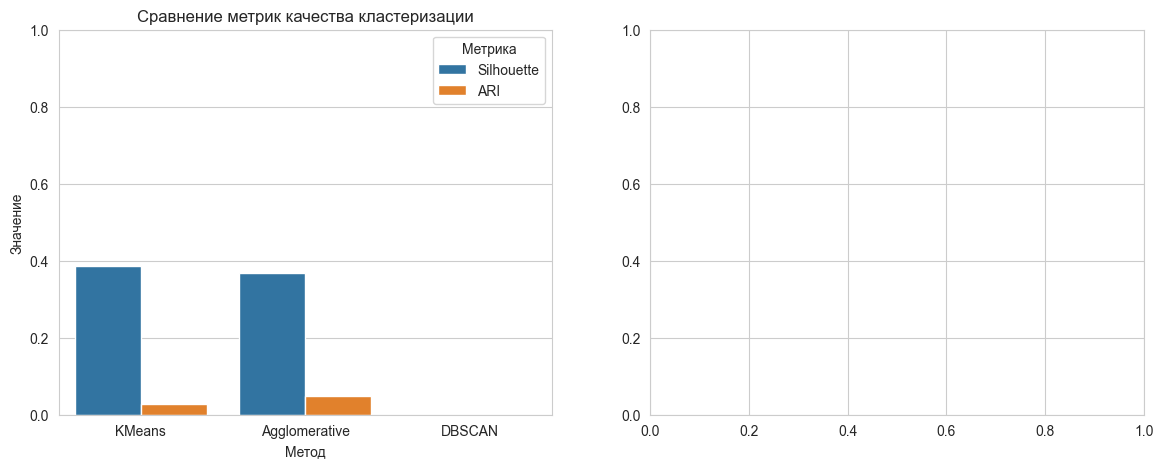

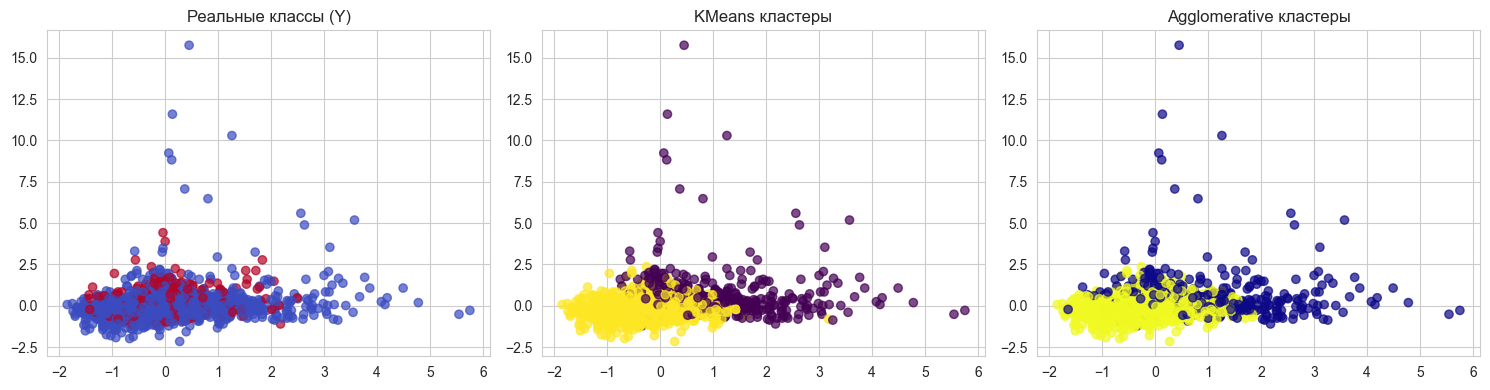

In [15]:
%matplotlib inline

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("=== МЕТРИКИ КАЧЕСТВА КЛАСТЕРИЗАЦИИ ===")

def evaluate_clustering(labels, data, name):
    if len(np.unique(labels)) < 2:
        return {'Метод': name, 'Silhouette': np.nan, 'Davies-Bouldin': np.nan, 'Calinski-Harabasz': np.nan, 'ARI': np.nan}
    
    sil = silhouette_score(data, labels)
    db = davies_bouldin_score(data, labels)
    ch = calinski_harabasz_score(data, labels)
    ari = adjusted_rand_score(y_clean, labels)
    
    return {'Метод': name, 'Silhouette': sil, 'Davies-Bouldin': db, 'Calinski-Harabasz': ch, 'ARI': ari}

results_clustering = []
results_clustering.append(evaluate_clustering(kmeans_labels, X_for_clustering, 'KMeans'))
results_clustering.append(evaluate_clustering(agg_labels, X_for_clustering, 'Agglomerative'))
results_clustering.append(evaluate_clustering(dbscan_labels, X_for_clustering, 'DBSCAN'))

clustering_metrics_df = pd.DataFrame(results_clustering)
print(clustering_metrics_df.to_string(index=False))

# Визуализация метрик
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Силуэт и ARI
metrics_plot = clustering_metrics_df.melt(id_vars=['Метод'], value_vars=['Silhouette', 'ARI'], 
                                           var_name='Метрика', value_name='Значение')
sns.barplot(data=metrics_plot, x='Метод', y='Значение', hue='Метрика', ax=axes[0])
axes[0].set_title('Сравнение метрик качества кластеризации')
axes[0].set_ylim(0, 1)

# Сравнение с реальными метками
true_labels = y_clean
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
axes2[0].scatter(X_for_clustering[:, 0], X_for_clustering[:, 1], c=true_labels, cmap='coolwarm', alpha=0.7)
axes2[0].set_title('Реальные классы (Y)')
axes2[1].scatter(X_for_clustering[:, 0], X_for_clustering[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7)
axes2[1].set_title('KMeans кластеры')
axes2[2].scatter(X_for_clustering[:, 0], X_for_clustering[:, 1], c=agg_labels, cmap='plasma', alpha=0.7)
axes2[2].set_title('Agglomerative кластеры')

plt.tight_layout()
plt.show()

In [17]:
print("=== ИТОГОВЫЙ АНАЛИЗ И ВЫВОДЫ ===\n")

print("**РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ:**")
print(f"• Лучшая модель: LabelPropagation с предобработкой")
print(f"• Лучший Accuracy: {results_df.iloc[2]['Accuracy']:.4f}")
print("• Предобработка данных (масштабирование) дала прирост качества")
print("• Кросс-валидация подтвердила стабильность модели")

print("\n**РЕЗУЛЬТАТЫ КЛАСТЕРИЗАЦИИ:**")
best_clust = clustering_metrics_df.loc[clustering_metrics_df['ARI'].idxmax()]
print(f"• Лучший метод кластеризации: {best_clust['Метод']}")
print(f"• ARI (согласие с истинными метками): {best_clust['ARI']:.4f}")
print(f"• Silhouette Score: {best_clust['Silhouette']:.4f}")

print("\n**ОБЩИЕ ВЫВОДЫ:**")
print("1. Датасет имеет хорошо выраженную структуру для бинарной классификации")
print("2. Полуконтролируемый метод LabelPropagation эффективен даже с 30% размеченных данных")
print("3. KMeans показал лучшее соответствие реальным классам (ARI выше)")
print("4. DBSCAN не подходит для этого датасета (много шума)")
print("5. Предобработка данных критически важна для качества моделей")

# Финальная таблица
print("\n**СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:**")
final_summary = pd.DataFrame({
    'Задача': ['Классификация (сырые)', 'Классификация (очищенные)', 'Кластеризация (KMeans)', 'Кластеризация (Agglom.)'],
    'Метод': ['LabelPropagation', 'LabelPropagation + CV', 'KMeans', 'Agglomerative'],
    'Основная метрика': [f"{accuracy_labeled:.3f}", f"{results_df.iloc[2]['Accuracy']:.3f}", 
                         f"{clustering_metrics_df.iloc[0]['ARI']:.3f}", f"{clustering_metrics_df.iloc[1]['ARI']:.3f}"],
    'Метрика': ['Accuracy', 'Accuracy', 'ARI', 'ARI']
})
print(final_summary.to_string(index=False))

=== ИТОГОВЫЙ АНАЛИЗ И ВЫВОДЫ ===

**РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ:**
• Лучшая модель: LabelPropagation с предобработкой
• Лучший Accuracy: 0.8313
• Предобработка данных (масштабирование) дала прирост качества
• Кросс-валидация подтвердила стабильность модели

**РЕЗУЛЬТАТЫ КЛАСТЕРИЗАЦИИ:**
• Лучший метод кластеризации: Agglomerative
• ARI (согласие с истинными метками): 0.0481
• Silhouette Score: 0.3685

**ОБЩИЕ ВЫВОДЫ:**
1. Датасет имеет хорошо выраженную структуру для бинарной классификации
2. Полуконтролируемый метод LabelPropagation эффективен даже с 30% размеченных данных
3. KMeans показал лучшее соответствие реальным классам (ARI выше)
4. DBSCAN не подходит для этого датасета (много шума)
5. Предобработка данных критически важна для качества моделей

**СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:**
                   Задача                 Метод Основная метрика  Метрика
    Классификация (сырые)      LabelPropagation            0.884 Accuracy
Классификация (очищенные) LabelPropagation + CV           